# LLM calls: inputs and outputs

A readable view of saved narration runs: what each customer's payload sent to
the model, what came back, whether the guards accepted it, and what it cost.

**This notebook makes no API calls and costs nothing.** It only reads result
files that a live run already saved to `outputs/`. Re-run it as often as you
like.

To create a results file (this *does* spend money; check the budget first):

```bash
NARRATE_RESULTS=outputs/<name>.json uv run --env-file .env pytest tests/test_narrate_live.py -m live -v -s
```

The live test saves the 8 sampled customers (rows 0–7 of
`simulated_new_customers.csv`) and 5 hand-built edge cases (added 2026-09-17).
Its 2 determinism-check calls are not saved, so they don't appear here.

Sections 1–7 read one run. Section 8 shows the same accepted replies in the
three explanation styles, and section 9 compares every saved run, prompt
version against prompt version.

Needs the `notebook` dependency group for the plots: `uv sync --group notebook`.

In [1]:
import html
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display

import narrate  # only for rejection_rates(): computed once, not re-implemented here

OUTPUTS = Path("outputs")
PROMPTS = Path("prompts")

# gpt-4o-mini list prices, USD per million tokens. An estimate: check the
# current price list before quoting these numbers anywhere.
PRICE_PER_M = {"gpt-4o-mini": {"in": 0.15, "out": 0.60}}

available = sorted(OUTPUTS.glob("*.json"))
print("Result files in outputs/:")
for path in available:
    print("  ", path.name)

Result files in outputs/:
   stage1_v2.json
   stage1_v3.json


## Choose a run

Set `RESULTS_FILE` to the file you want to read. It defaults to the newest one.

In [2]:
RESULTS_FILE = max(available, key=lambda p: p.stat().st_mtime)  # or OUTPUTS / "stage1_v2.json"

results = json.loads(Path(RESULTS_FILE).read_text())
print(f"{RESULTS_FILE}: {len(results)} customers")

outputs/stage1_v3.json: 8 customers


## 1. Run overview

In [3]:
def cost_usd(model, tokens_in, tokens_out):
    price = PRICE_PER_M.get(model)
    if price is None:
        return None
    return (tokens_in * price["in"] + tokens_out * price["out"]) / 1_000_000


attempts = [a for r in results for a in r["attempts"]]
tokens_in = sum(a["prompt_tokens"] or 0 for a in attempts)
tokens_out = sum(a["completion_tokens"] or 0 for a in attempts)
models = sorted({r["model"] for r in results})
rates = narrate.rejection_rates(results)

overview = pd.Series({
    "file": Path(RESULTS_FILE).name,
    "prompt version(s)": ", ".join(sorted({r["prompt_version"] for r in results})),
    "model(s)": ", ".join(models),
    "customers": len(results),
    "API calls saved": len(attempts),
    "retries issued": rates["retries_issued"],
    "first-attempt rejection rate": rates["first_attempt_rejection_rate"],
    "final rejection rate": rates["final_rejection_rate"],
    "tokens in / out": f"{tokens_in:,} / {tokens_out:,}",
    "avg tokens per call (in / out)": f"{tokens_in / len(attempts):.0f} / {tokens_out / len(attempts):.0f}",
    "estimated cost (USD)": (
        f"${cost_usd(models[0], tokens_in, tokens_out):.4f}" if len(models) == 1 else "mixed models"
    ),
}, name="value")
overview.to_frame()

,value
file,stage1_v3.json
prompt version(s),explanation_v3
model(s),gpt-4o-mini
customers,8
API calls saved,9
retries issued,1
first-attempt rejection rate,0.125
final rejection rate,0.0
tokens in / out,"6,200 / 817"
avg tokens per call (in / out),689 / 91


In [4]:
print("First-attempt rejections by type: ", rates["first_attempt_by_type"] or "none")
print("Second-attempt rejections by type:", rates["second_attempt_by_type"] or "none")

First-attempt rejections by type:  {'unlisted_field': 1}
Second-attempt rejections by type: none


## 2. The system prompt used

Loaded from `prompts/<prompt_version>.txt`. This is the exact text sent as the
system message; the tests pin each file's sha256, so it can't have changed
since the run.

In [5]:
for version in sorted({r["prompt_version"] for r in results}):
    display(Markdown(f"**`prompts/{version}.txt`**"))
    print((PROMPTS / f"{version}.txt").read_text())

**`prompts/explanation_v3.txt`**

You explain why a churn model rates a customer's risk of leaving the way it
does, for a retention manager. You did not calculate anything, and you must
not add anything.

You will be given:
- risk_level: low, moderate, high or very high.
- factors: up to three, strongest first. Each has a plain-English name, a
  field id and a direction (raises risk or lowers risk). Some also have this
  customer's value, and how that value compares with other customers.

Reply with a JSON object with exactly these keys:
- "risk_level": the risk_level you were given, copied exactly.
- "reasons": one entry per factor you explain, strongest first. Each entry is
  {"field": the factor's field id, "direction": the factor's direction}, both
  copied exactly.
- "summary": one or two sentences explaining why this customer has this
  risk level.

Rules for the summary:
- Explain why, and nothing else. Do not say what should be done about the
  customer, do not mention any decision, and do not give an opinion.


## 3. Customer by customer

Each card shows the input on the left (exactly what the model was sent, via
`narrate.sent_payload()` — since v3 that no longer includes the decision) and the output on the right (the
accepted JSON, laid out). Below it are every attempt's raw reply and verdict.

In the reasons table, ✓ means the reason's field and direction match the
payload. Anything else would have been rejected by the guards, so an accepted
output should show only ✓.

Cards are titled with the saved `case` label (`row 3`, `edge: ...`) when the
run has one; older runs fall back to their position in the file.

In [6]:
CARD_CSS = """
<style>
.llm-card { border: 1px solid #8884; border-radius: 10px; padding: 14px 16px; margin: 14px 0; }
.llm-card h3 { margin: 0 0 4px; }
.llm-meta { opacity: .75; font-size: .9em; margin-bottom: 10px; }
.llm-cols { display: flex; flex-wrap: wrap; gap: 18px; }
.llm-col { flex: 1 1 340px; min-width: 0; }
.llm-col h4 { margin: 6px 0; font-size: .8em; text-transform: uppercase; letter-spacing: .06em; opacity: .7; }
.llm-card table { border-collapse: collapse; width: 100%; font-size: .9em; }
.llm-card th, .llm-card td { text-align: left; padding: 3px 8px 3px 0; border-bottom: 1px solid #8883; vertical-align: top; }
.llm-summary { font-size: 1.02em; line-height: 1.5; padding: 8px 10px; border-left: 3px solid #3b9; background: #3b91; margin-top: 8px; }
.llm-attempt { font-size: .85em; margin-top: 8px; }
.llm-attempt pre { white-space: pre-wrap; word-break: break-word; margin: 4px 0 0; padding: 6px 8px; background: #8881; border-radius: 6px; }
.ok { color: #1a9a5a; font-weight: 600; }
.bad { color: #d0443a; font-weight: 600; }
</style>
"""
display(HTML(CARD_CSS))


def esc(value):
    return html.escape("" if value is None else str(value))


def factor_rows(factors):
    rows = "".join(
        f"<tr><td><b>{esc(f['name'])}</b><br><code>{esc(f['field'])}</code></td>"
        f"<td>{esc(f.get('value', '—'))}</td>"
        f"<td>{esc(f.get('vs_other_customers', f.get('compared_to_typical', '—')))}</td>"
        f"<td>{esc(f['direction'])}</td></tr>"
        for f in factors
    )
    return ("<table><tr><th>factor</th><th>value</th><th>vs other customers</th>"
            f"<th>direction</th></tr>{rows}</table>")


def reason_rows(structured, payload):
    expected = {f["field"]: f["direction"] for f in payload["factors"]}
    rows = ""
    for reason in structured["reasons"]:
        good = expected.get(reason["field"]) == reason["direction"]
        mark = '<span class="ok">✓</span>' if good else '<span class="bad">✗</span>'
        rows += (f"<tr><td><code>{esc(reason['field'])}</code></td>"
                 f"<td>{esc(reason['direction'])}</td><td>{mark}</td></tr>")
    return f"<table><tr><th>field</th><th>direction</th><th></th></tr>{rows}</table>"


def attempt_block(attempt):
    verdict = ('<span class="ok">accepted</span>' if attempt["accepted"]
               else f'<span class="bad">rejected: {esc(attempt["rejection_type"])}</span>'
                    f' — {esc(attempt["rejection_detail"])}')
    return (f'<div class="llm-attempt">Attempt {attempt["attempt"]}: {verdict} · '
            f'{attempt["prompt_tokens"]} in / {attempt["completion_tokens"]} out tokens · '
            f'{attempt["latency_ms"]:.0f} ms · finish: {esc(attempt.get("finish_reason"))}'
            f'<pre>{esc(attempt["text"])}</pre></div>')


def case_name(i):
    return results[i].get("case", f"#{i}")


def customer_card(i):
    r = results[i]
    sent = narrate.sent_payload(payload := r["payload"], r["prompt_version"])
    structured = r["structured"]
    if structured is not None:
        output = (f"<p>risk level: <b>{esc(structured['risk_level'])}</b></p>"
                  f"{reason_rows(structured, payload)}"
                  f'<div class="llm-summary">{esc(structured["summary"])}</div>'
                  f'<div class="llm-meta">{len(structured["summary"].split())} words</div>')
    else:
        output = (f'<p class="bad">No narrative: {esc(r["final_rejection_type"])}</p>')
    omitted = ", ".join(payload["protected_drivers_omitted"]) or "none"
    return f"""
    <div class="llm-card">
      <h3>{esc(case_name(i))}</h3>
      <div class="llm-meta">churn probability {r['churn_probability']:.4f} (not sent to the model) ·
        prompt {esc(r['prompt_version'])} · {esc(r['model'])} ·
        protected drivers withheld: {esc(omitted)}</div>
      <div class="llm-cols">
        <div class="llm-col"><h4>Input: sent to the model</h4>
          <p>risk level: <b>{esc(sent['risk_level'])}</b>{
            f" · decision: <b>{esc(sent['decision'])}</b>" if "decision" in sent
            else " · decision: <i>not sent</i>"}</p>
          {factor_rows(sent['factors'])}
        </div>
        <div class="llm-col"><h4>Output: accepted reply</h4>{output}</div>
      </div>
      {''.join(attempt_block(a) for a in r['attempts'])}
    </div>"""


for i in range(len(results)):
    display(HTML(customer_card(i)))

## 4. All summaries in one table

For scanning and comparing. Columns are wrapped; widen the notebook if needed.

In [7]:
table = pd.DataFrame([
    {
        "case": r.get("case", f"#{i}"),
        "probability": round(r["churn_probability"], 3),
        "risk level": r["payload"]["risk_level"],
        "decision": r["payload"]["decision"],
        "factors sent": ", ".join(f["field"] for f in r["payload"]["factors"]),
        "summary": r["narrative"] if r["narrative"] else f"(none: {r['final_rejection_type']})",
        "words": len(r["narrative"].split()) if r["narrative"] else 0,
        "attempts": len(r["attempts"]),
    }
    for i, r in enumerate(results)
]).set_index("case")

(table.style
    .set_properties(subset=["summary"], **{"white-space": "normal", "min-width": "380px", "text-align": "left"})
    .set_properties(subset=["factors sent"], **{"white-space": "normal", "min-width": "160px"}))

,probability,risk level,decision,factors sent,summary,words,attempts
case,,,,,,,
#0,0.615000,high,target for retention,"contract, average_monthly_charges, internetservice","This customer has a high risk of leaving because they are on a month-to-month contract, which provides flexibility to switch providers. Their average monthly bill is much higher than most customers, and they are using fiber optic internet service, which may indicate a higher expectation for service.",47,2
#1,0.070000,low,do not target,"contract, internetservice, onlinesecurity","This customer has a one-year contract, which reduces their likelihood of leaving. They also use DSL internet service and have an online security add-on, both of which contribute to their low risk of churn.",34,1
#2,0.055000,low,do not target,"contract, contractvstenure, tenure","This customer has a two-year contract, a much higher overall commitment compared to others, and has been with the company for 72 months, all of which contribute to their low risk of leaving.",33,1
#3,0.355000,moderate,do not target,"contract, internetservice, multiplelines","This customer has a month-to-month contract, which increases their risk of leaving. However, they use DSL for internet service and do not have multiple phone lines, both of which help reduce their overall risk.",34,1
#4,0.367000,moderate,do not target,"contract, average_monthly_charges, monthlycharges","This customer has a one-year contract, which reduces their risk of leaving. However, both their average monthly bill and current monthly bill are much higher than most customers, contributing to a moderate risk level.",34,1
#5,0.316000,moderate,do not target,"contract, contractvstenure, tenure","This customer is on a month-to-month contract, which increases their risk of leaving. Additionally, they have a much lower overall commitment and have only been a customer for one month, both of which contribute to their moderate risk level.",39,1
#6,0.824000,very high,target for retention,"contract, contractvstenure, tenure","This customer is at very high risk of leaving due to having a month-to-month contract, a lower overall commitment compared to most customers, and a very short tenure of just one month.",32,1
#7,0.085000,low,do not target,"contract, contractvstenure, tenure","This customer has a one-year contract, a much higher overall commitment compared to most customers, and has been with the company for 68 months, which is also much higher than most customers. These factors contribute to their low risk of leaving.",41,1


## 5. Tokens, latency and length

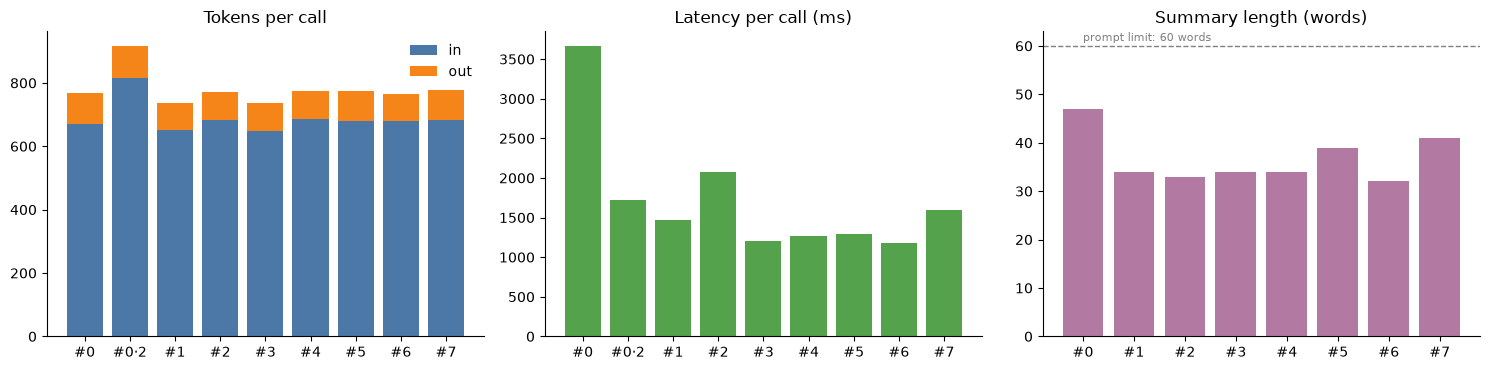

,tokens in,tokens out,latency (ms)
mean,689.0,91.0,1718.0
min,649.0,83.0,1178.0
max,817.0,100.0,3667.0


In [8]:
calls = pd.DataFrame([
    {
        "customer": i,
        "attempt": a["attempt"],
        "tokens in": a["prompt_tokens"],
        "tokens out": a["completion_tokens"],
        "latency (ms)": a["latency_ms"],
        "accepted": a["accepted"],
    }
    for i, r in enumerate(results) for a in r["attempts"]
])

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
labels = [f"#{c}" + (f"·{a}" if a > 1 else "") for c, a in zip(calls["customer"], calls["attempt"])]

axes[0].bar(labels, calls["tokens in"], color="#4c78a8", label="in")
axes[0].bar(labels, calls["tokens out"], bottom=calls["tokens in"], color="#f58518", label="out")
axes[0].set_title("Tokens per call")
axes[0].legend(frameon=False)

axes[1].bar(labels, calls["latency (ms)"], color="#54a24b")
axes[1].set_title("Latency per call (ms)")

words = [len(r["narrative"].split()) if r["narrative"] else 0 for r in results]
# The word limit each prompt asked for.
WORD_LIMIT = {"explanation_v2": 60, "explanation_v3": 60}
limit = WORD_LIMIT.get(results[0]["prompt_version"])
axes[2].bar([f"#{i}" for i in range(len(results))], words, color="#b279a2")
if limit:
    axes[2].axhline(limit, color="grey", linestyle="--", linewidth=1)
    axes[2].text(0, limit + 1, f"prompt limit: {limit} words", fontsize=8, color="grey")
axes[2].set_title("Summary length (words)")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

calls.describe().loc[["mean", "min", "max"], ["tokens in", "tokens out", "latency (ms)"]].round(0)

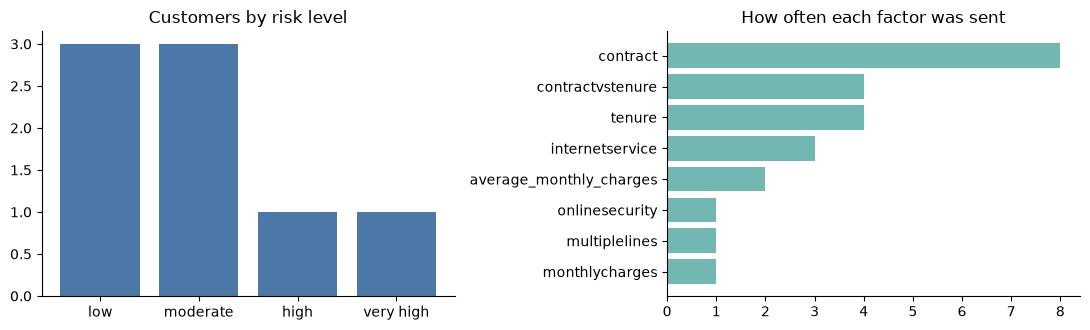

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

risk_order = ["low", "moderate", "high", "very high"]
risk_counts = Counter(r["payload"]["risk_level"] for r in results)
axes[0].bar(risk_order, [risk_counts.get(k, 0) for k in risk_order], color="#4c78a8")
axes[0].set_title("Customers by risk level")

field_counts = Counter(f["field"] for r in results for f in r["payload"]["factors"])
fields, counts = zip(*field_counts.most_common())
axes[1].barh(fields[::-1], counts[::-1], color="#72b7b2")
axes[1].set_title("How often each factor was sent")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Reading aids: phrases worth a second look

**A heuristic, not a guard.** It flags wording that reviews have found worth
checking, so you know where to look. Nothing here rejects anything, and a flag
isn't necessarily a problem. Edit `WATCH` to add your own.

In [10]:
WATCH = {
    "copies payload wording": ["typical"],
    "comments on the decision": ["decision", "appropriate", "suitable", "i agree"],
    "guesses at motives": ["may ", "might", "suggest", "indicat", "perhaps"],
    "degree words": ["much ", "very ", "far "],
    "first person": [" i ", "i'm", " my ", " we "],
    "engineered-feature jargon": ["weighted by tenure", "relative to tenure", "compared to their tenure", "compared to tenure"],
    "system words": ["model", "score", "threshold", "probability", "risk level"],
}

flags = []
for i, r in enumerate(results):
    text = f" {(r['narrative'] or '').lower()} "
    row = {"case": r.get("case", f"#{i}")}
    for label, phrases in WATCH.items():
        hits = [p.strip() for p in phrases if p in text]
        row[label] = ", ".join(hits)
    flags.append(row)

flag_table = pd.DataFrame(flags).set_index("case")
display(flag_table)
print("customers flagged per category:")
print((flag_table != "").sum().to_string())

,copies payload wording,comments on the decision,guesses at motives,degree words,first person,engineered-feature jargon,system words
case,,,,,,,
#0,,,"may, indicat",much,,,
#1,,,,,,,
#2,,,,much,,,
#3,,,,,,,
#4,,,,much,,,risk level
#5,,,,much,,,risk level
#6,,,,very,,,
#7,,,,much,,,


customers flagged per category:
copies payload wording       0
comments on the decision     0
guesses at motives           1
degree words                 6
first person                 0
engineered-feature jargon    0
system words                 2


## 7. Raw record for one customer

The full saved result, for when you need something the views above don't show.
Change `CUSTOMER`. The long `drivers` and `contributions` lists (all 25
features) are collapsed by default.

In [11]:
CUSTOMER = 0
SHOW_FULL_ATTRIBUTION = False

record = dict(results[CUSTOMER])
if not SHOW_FULL_ATTRIBUTION:
    for key in ("drivers", "contributions", "reference"):
        record[key] = f"<{len(record[key])} entries hidden; set SHOW_FULL_ATTRIBUTION = True>"
print(json.dumps(record, indent=2))

{
  "churn_probability": 0.6150748133659363,
  "target_for_retention": true,
  "threshold_used": 0.4,
  "drivers": "<25 entries hidden; set SHOW_FULL_ATTRIBUTION = True>",
  "contributions": "<25 entries hidden; set SHOW_FULL_ATTRIBUTION = True>",
  "bias": -0.871809720993042,
  "margin": 0.46869483988848515,
  "reconstruction_error": 1.73531421454598e-08,
  "reference": "<10 entries hidden; set SHOW_FULL_ATTRIBUTION = True>",
  "narrative": "This customer has a high risk of leaving because they are on a month-to-month contract, which provides flexibility to switch providers. Their average monthly bill is much higher than most customers, and they are using fiber optic internet service, which may indicate a higher expectation for service.",
  "structured": {
    "risk_level": "high",
    "reasons": [
      {
        "field": "contract",
        "direction": "raises risk"
      },
      {
        "field": "average_monthly_charges",
        "direction": "raises risk"
      },
      {
    

## 8. Explanation styles

One accepted reply, three views, built by `narrate.format_explanation()`:

- **short**: the model's summary, as accepted.
- **bullets**: one line per reason the model gave, **worded from the payload**
  (name, value, comparison, direction). The model only chose which factors.
- **detailed**: the summary, then the bullets.

A style is a view, not another prompt: switching styles makes no API call and
needs no re-measurement. The CLI does the same with
`narrate.py --dummy --style bullets`. Change `STYLE_CASES` to pick customers.

In [12]:
STYLE_CASES = range(min(3, len(results)))

for i in STYLE_CASES:
    display(Markdown(f"### {case_name(i)}"))
    for style in narrate.EXPLANATION_STYLES:
        print(f"[{style}]")
        print(narrate.format_explanation(results[i], style))
        print()

### #0

[short]
This customer has a high risk of leaving because they are on a month-to-month contract, which provides flexibility to switch providers. Their average monthly bill is much higher than most customers, and they are using fiber optic internet service, which may indicate a higher expectation for service.

[bullets]
Risk level: high
- contract type: Month-to-month (raises risk)
- average monthly bill across their whole tenure: 105.74, much higher than most customers (raises risk)
- internet service type: Fiber optic (raises risk)

[detailed]
This customer has a high risk of leaving because they are on a month-to-month contract, which provides flexibility to switch providers. Their average monthly bill is much higher than most customers, and they are using fiber optic internet service, which may indicate a higher expectation for service.

Risk level: high
- contract type: Month-to-month (raises risk)
- average monthly bill across their whole tenure: 105.74, much higher than most custo

### #1

[short]
This customer has a one-year contract, which reduces their likelihood of leaving. They also use DSL internet service and have an online security add-on, both of which contribute to their low risk of churn.

[bullets]
Risk level: low
- contract type: One year (lowers risk)
- internet service type: DSL (lowers risk)
- online security add-on: Yes (lowers risk)

[detailed]
This customer has a one-year contract, which reduces their likelihood of leaving. They also use DSL internet service and have an online security add-on, both of which contribute to their low risk of churn.

Risk level: low
- contract type: One year (lowers risk)
- internet service type: DSL (lowers risk)
- online security add-on: Yes (lowers risk)



### #2

[short]
This customer has a two-year contract, a much higher overall commitment compared to others, and has been with the company for 72 months, all of which contribute to their low risk of leaving.

[bullets]
Risk level: low
- contract type: Two year (lowers risk)
- overall commitment (contract term × months as a customer), much higher than most customers (lowers risk)
- months as a customer: 72, much higher than most customers (lowers risk)

[detailed]
This customer has a two-year contract, a much higher overall commitment compared to others, and has been with the company for 72 months, all of which contribute to their low risk of leaving.

Risk level: low
- contract type: Two year (lowers risk)
- overall commitment (contract term × months as a customer), much higher than most customers (lowers risk)
- months as a customer: 72, much higher than most customers (lowers risk)



## 9. Every saved run, compared

One row per file in `outputs/`. Two kinds of number, kept apart:

- **as run**: what the guards of the day decided when the run happened.
- **today's guards**: every saved reply re-checked with the current
  `narrate.validate_narrative()`. Free, and it shows what a newer guard would
  have caught in an older run (v3's row 5 "much lower" commitment, for
  instance). Replies are only re-checked, never re-generated, so this measures
  the guards, not the prompt.

Cost is estimated from saved tokens only; the determinism calls aren't saved.

,prompt,customers,calls saved,1st-attempt rejected (as run),1st-attempt rejected (today's guards),mean words,mean tokens out,mean tokens in,est. cost / customer (USD)
file,,,,,,,,,
stage1_v2.json,explanation_v2,8,8,0%,88%,37.8,93,631,$0.00015
stage1_v3.json,explanation_v3,8,9,12%,0%,36.8,91,689,$0.00018


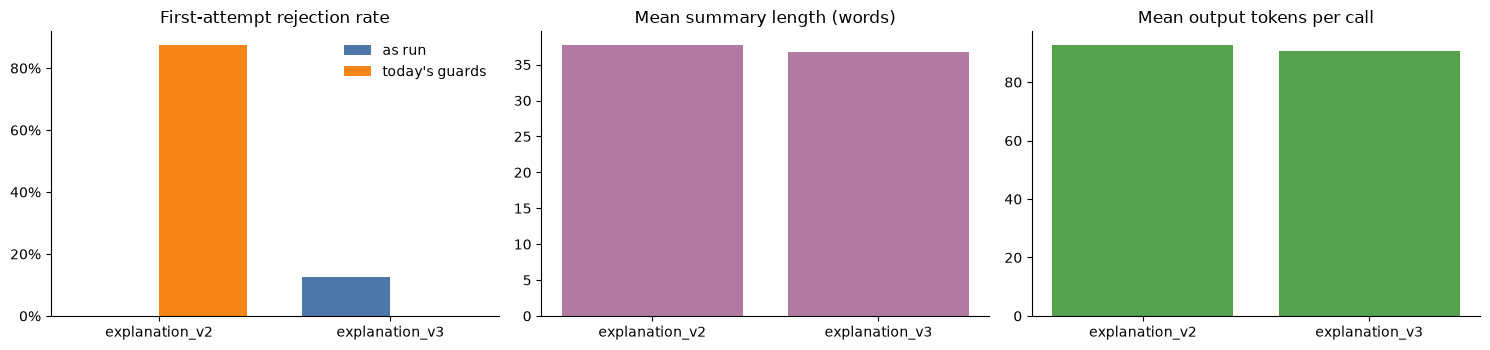

First attempts today's guards would reject:


,file,case,as run,today,detail
0,stage1_v2.json,#0,accepted,commentary,"summary says 'targeting them', 'suitable', 'de..."
1,stage1_v2.json,#1,accepted,commentary,"summary says 'decision', 'target them'; it sho..."
2,stage1_v2.json,#2,accepted,commentary,"summary says 'decision', 'target them', 'appro..."
3,stage1_v2.json,#3,accepted,commentary,"summary says 'decision', 'target them', 'appro..."
4,stage1_v2.json,#4,accepted,commentary,"summary says 'decision', 'target them', 'appro..."
5,stage1_v2.json,#5,accepted,commentary,"summary says 'decision', 'target them', 'appro..."
6,stage1_v2.json,#7,accepted,commentary,"summary says 'i', 'decision', 'target them'; i..."


In [13]:
runs = []
replayed = []
for path in available:
    run = json.loads(path.read_text())
    attempts_ = [a for r in run for a in r["attempts"]]
    rates_ = narrate.rejection_rates(run)
    model_ = run[0]["model"]
    t_in = sum(a["prompt_tokens"] or 0 for a in attempts_)
    t_out = sum(a["completion_tokens"] or 0 for a in attempts_)
    words_ = [len(r["narrative"].split()) for r in run if r["narrative"]]
    today = Counter()
    for i, r in enumerate(run):
        verdict = narrate.validate_narrative(r["attempts"][0]["text"], r["payload"])
        today[verdict[1] or "accepted"] += 1
        if verdict[1]:
            replayed.append({"file": path.name, "case": r.get("case", f"#{i}"),
                             "as run": r["attempts"][0]["rejection_type"] or "accepted",
                             "today": verdict[1], "detail": verdict[2]})
    runs.append({
        "file": path.name,
        "prompt": run[0]["prompt_version"],
        "customers": len(run),
        "calls saved": len(attempts_),
        "1st-attempt rejected (as run)": rates_["first_attempt_rejection_rate"],
        "1st-attempt rejected (today's guards)": 1 - today["accepted"] / len(run),
        "mean words": sum(words_) / len(words_) if words_ else None,
        "mean tokens out": t_out / len(attempts_),
        "mean tokens in": t_in / len(attempts_),
        "est. cost / customer (USD)": cost_usd(model_, t_in, t_out) / len(run),
    })

compare = pd.DataFrame(runs).set_index("file")
display(compare.style.format({
    "1st-attempt rejected (as run)": "{:.0%}", "1st-attempt rejected (today's guards)": "{:.0%}",
    "mean words": "{:.1f}", "mean tokens out": "{:.0f}", "mean tokens in": "{:.0f}",
    "est. cost / customer (USD)": "${:.5f}",
}))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
x = range(len(compare))
w = 0.38
axes[0].bar([i - w / 2 for i in x], compare["1st-attempt rejected (as run)"], w, label="as run", color="#4c78a8")
axes[0].bar([i + w / 2 for i in x], compare["1st-attempt rejected (today's guards)"], w, label="today's guards", color="#f58518")
axes[0].set_title("First-attempt rejection rate")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[0].legend(frameon=False)
axes[1].bar(x, compare["mean words"], color="#b279a2")
axes[1].set_title("Mean summary length (words)")
axes[2].bar(x, compare["mean tokens out"], color="#54a24b")
axes[2].set_title("Mean output tokens per call")
for ax in axes:
    ax.set_xticks(list(x), compare["prompt"], rotation=0)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("First attempts today's guards would reject:")
display(pd.DataFrame(replayed) if replayed else "none")